In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['hatch.linewidth'] = 0.5

[]


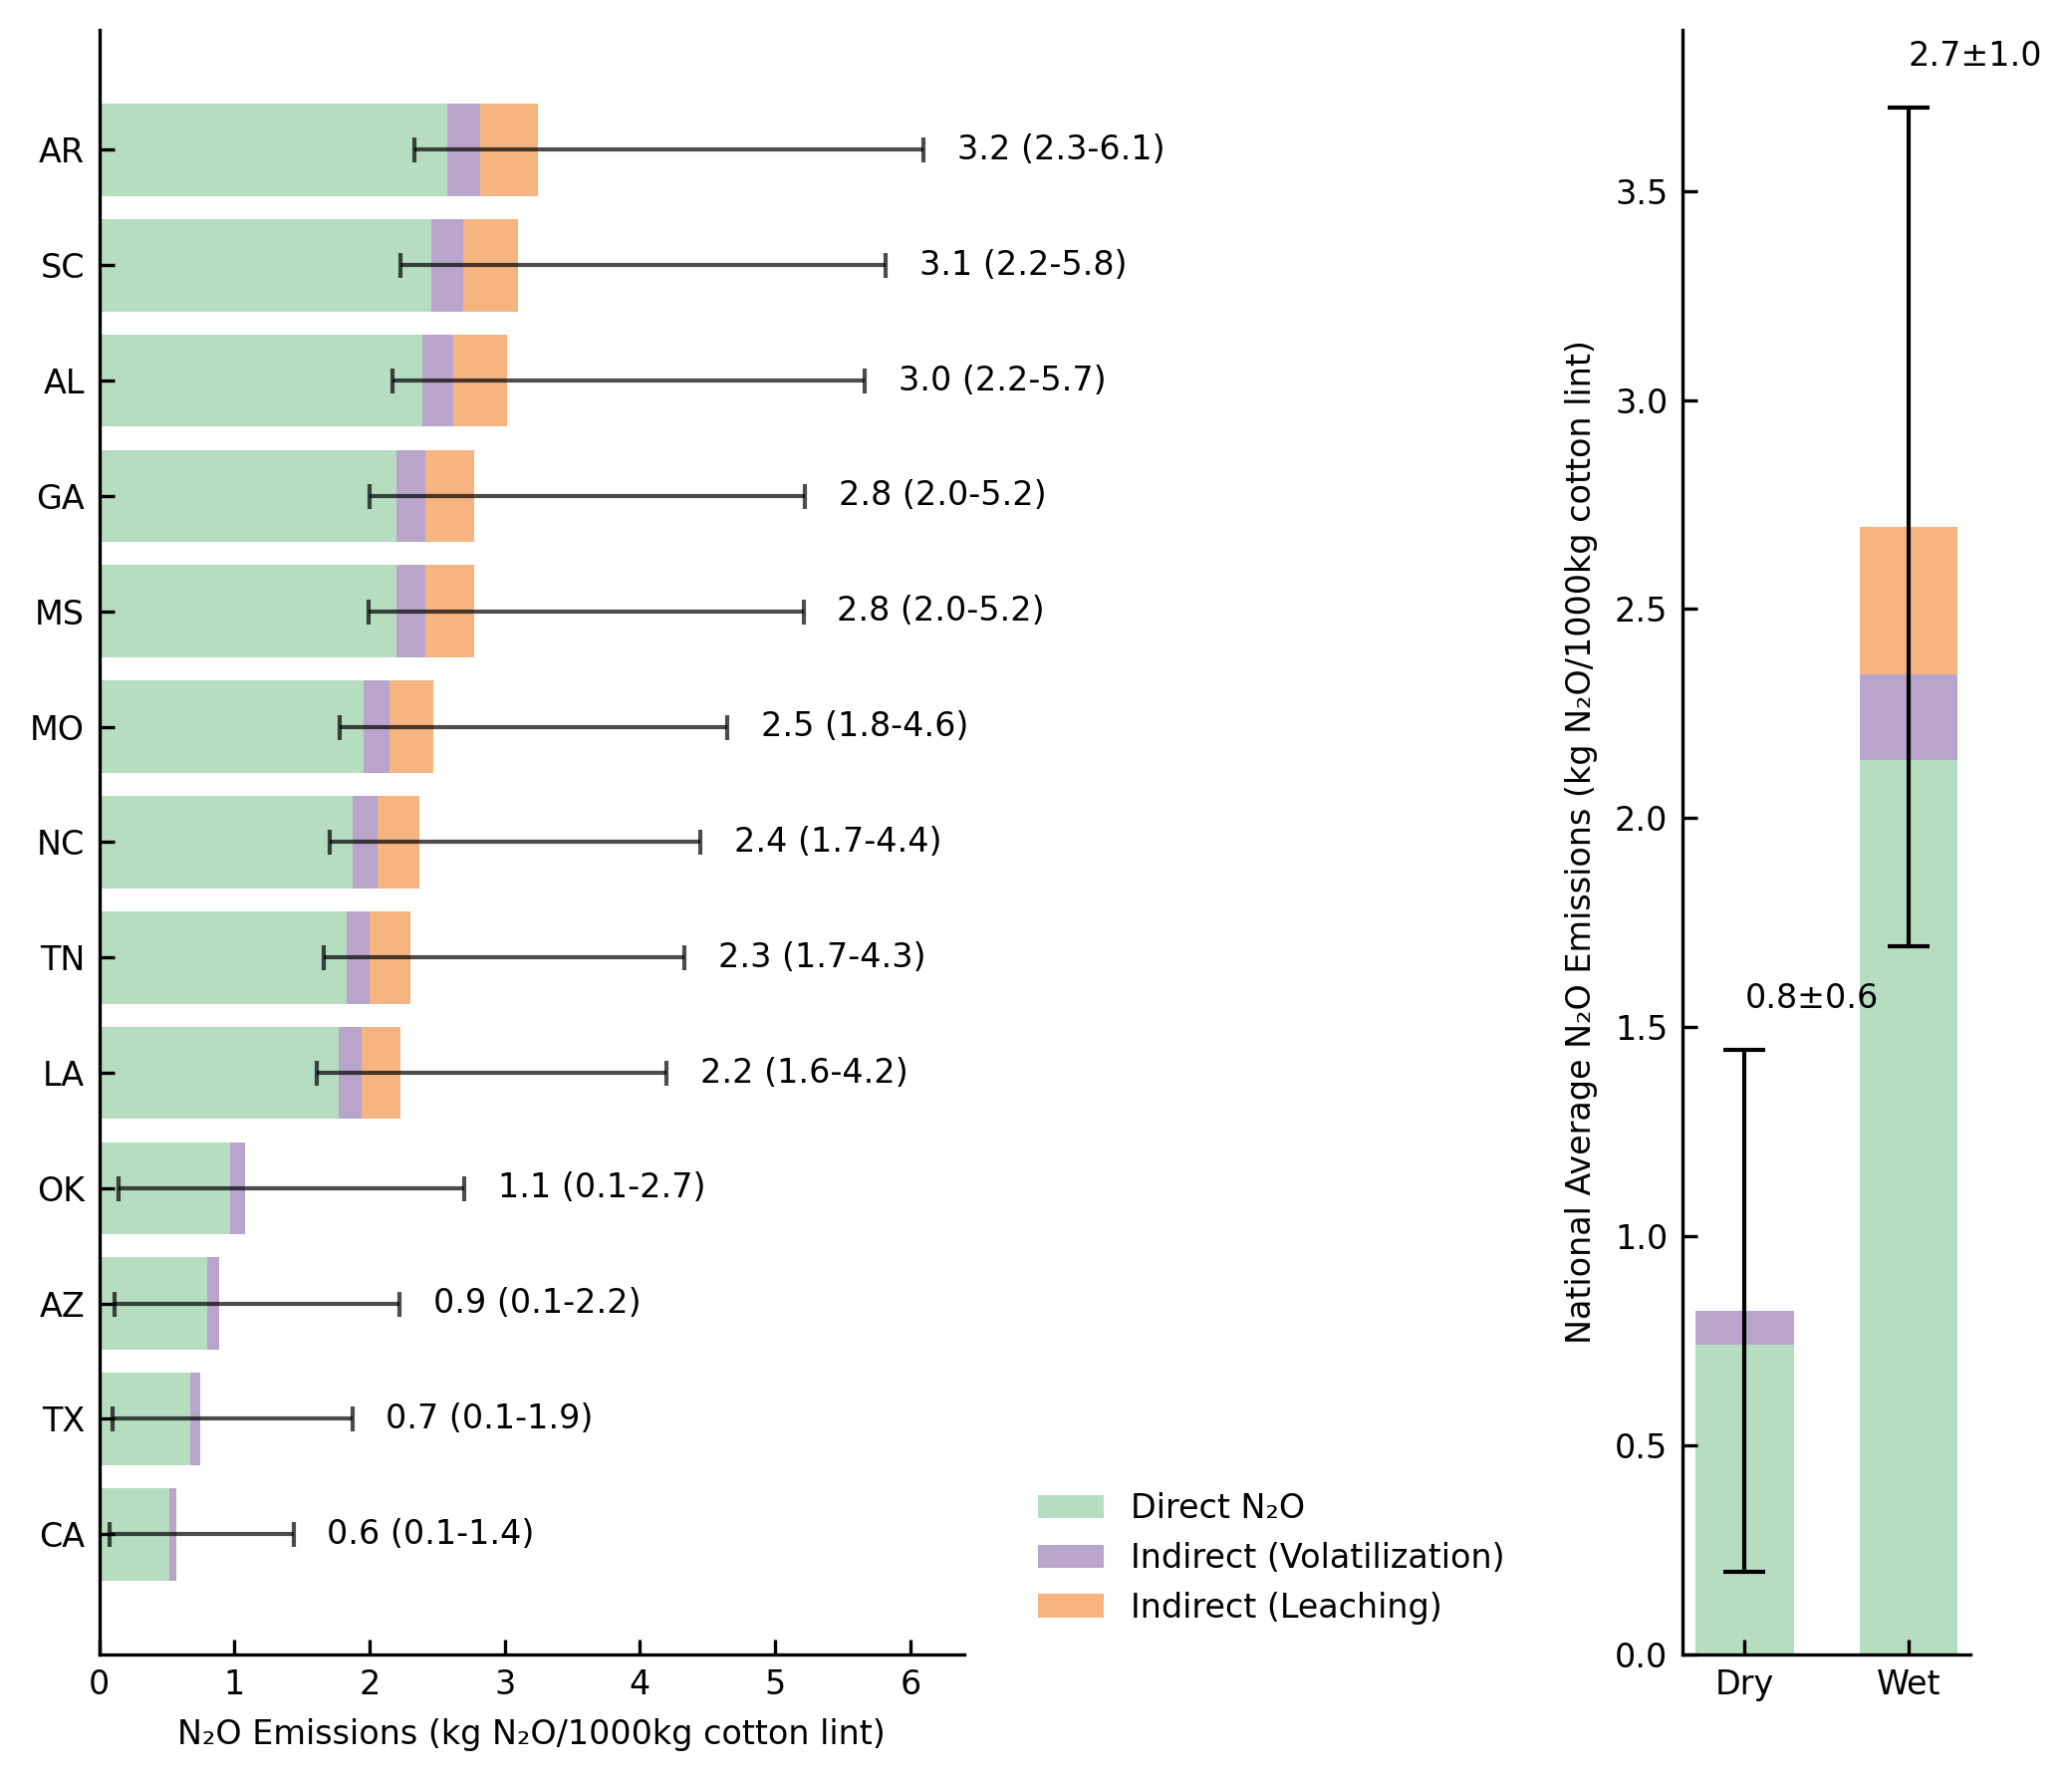

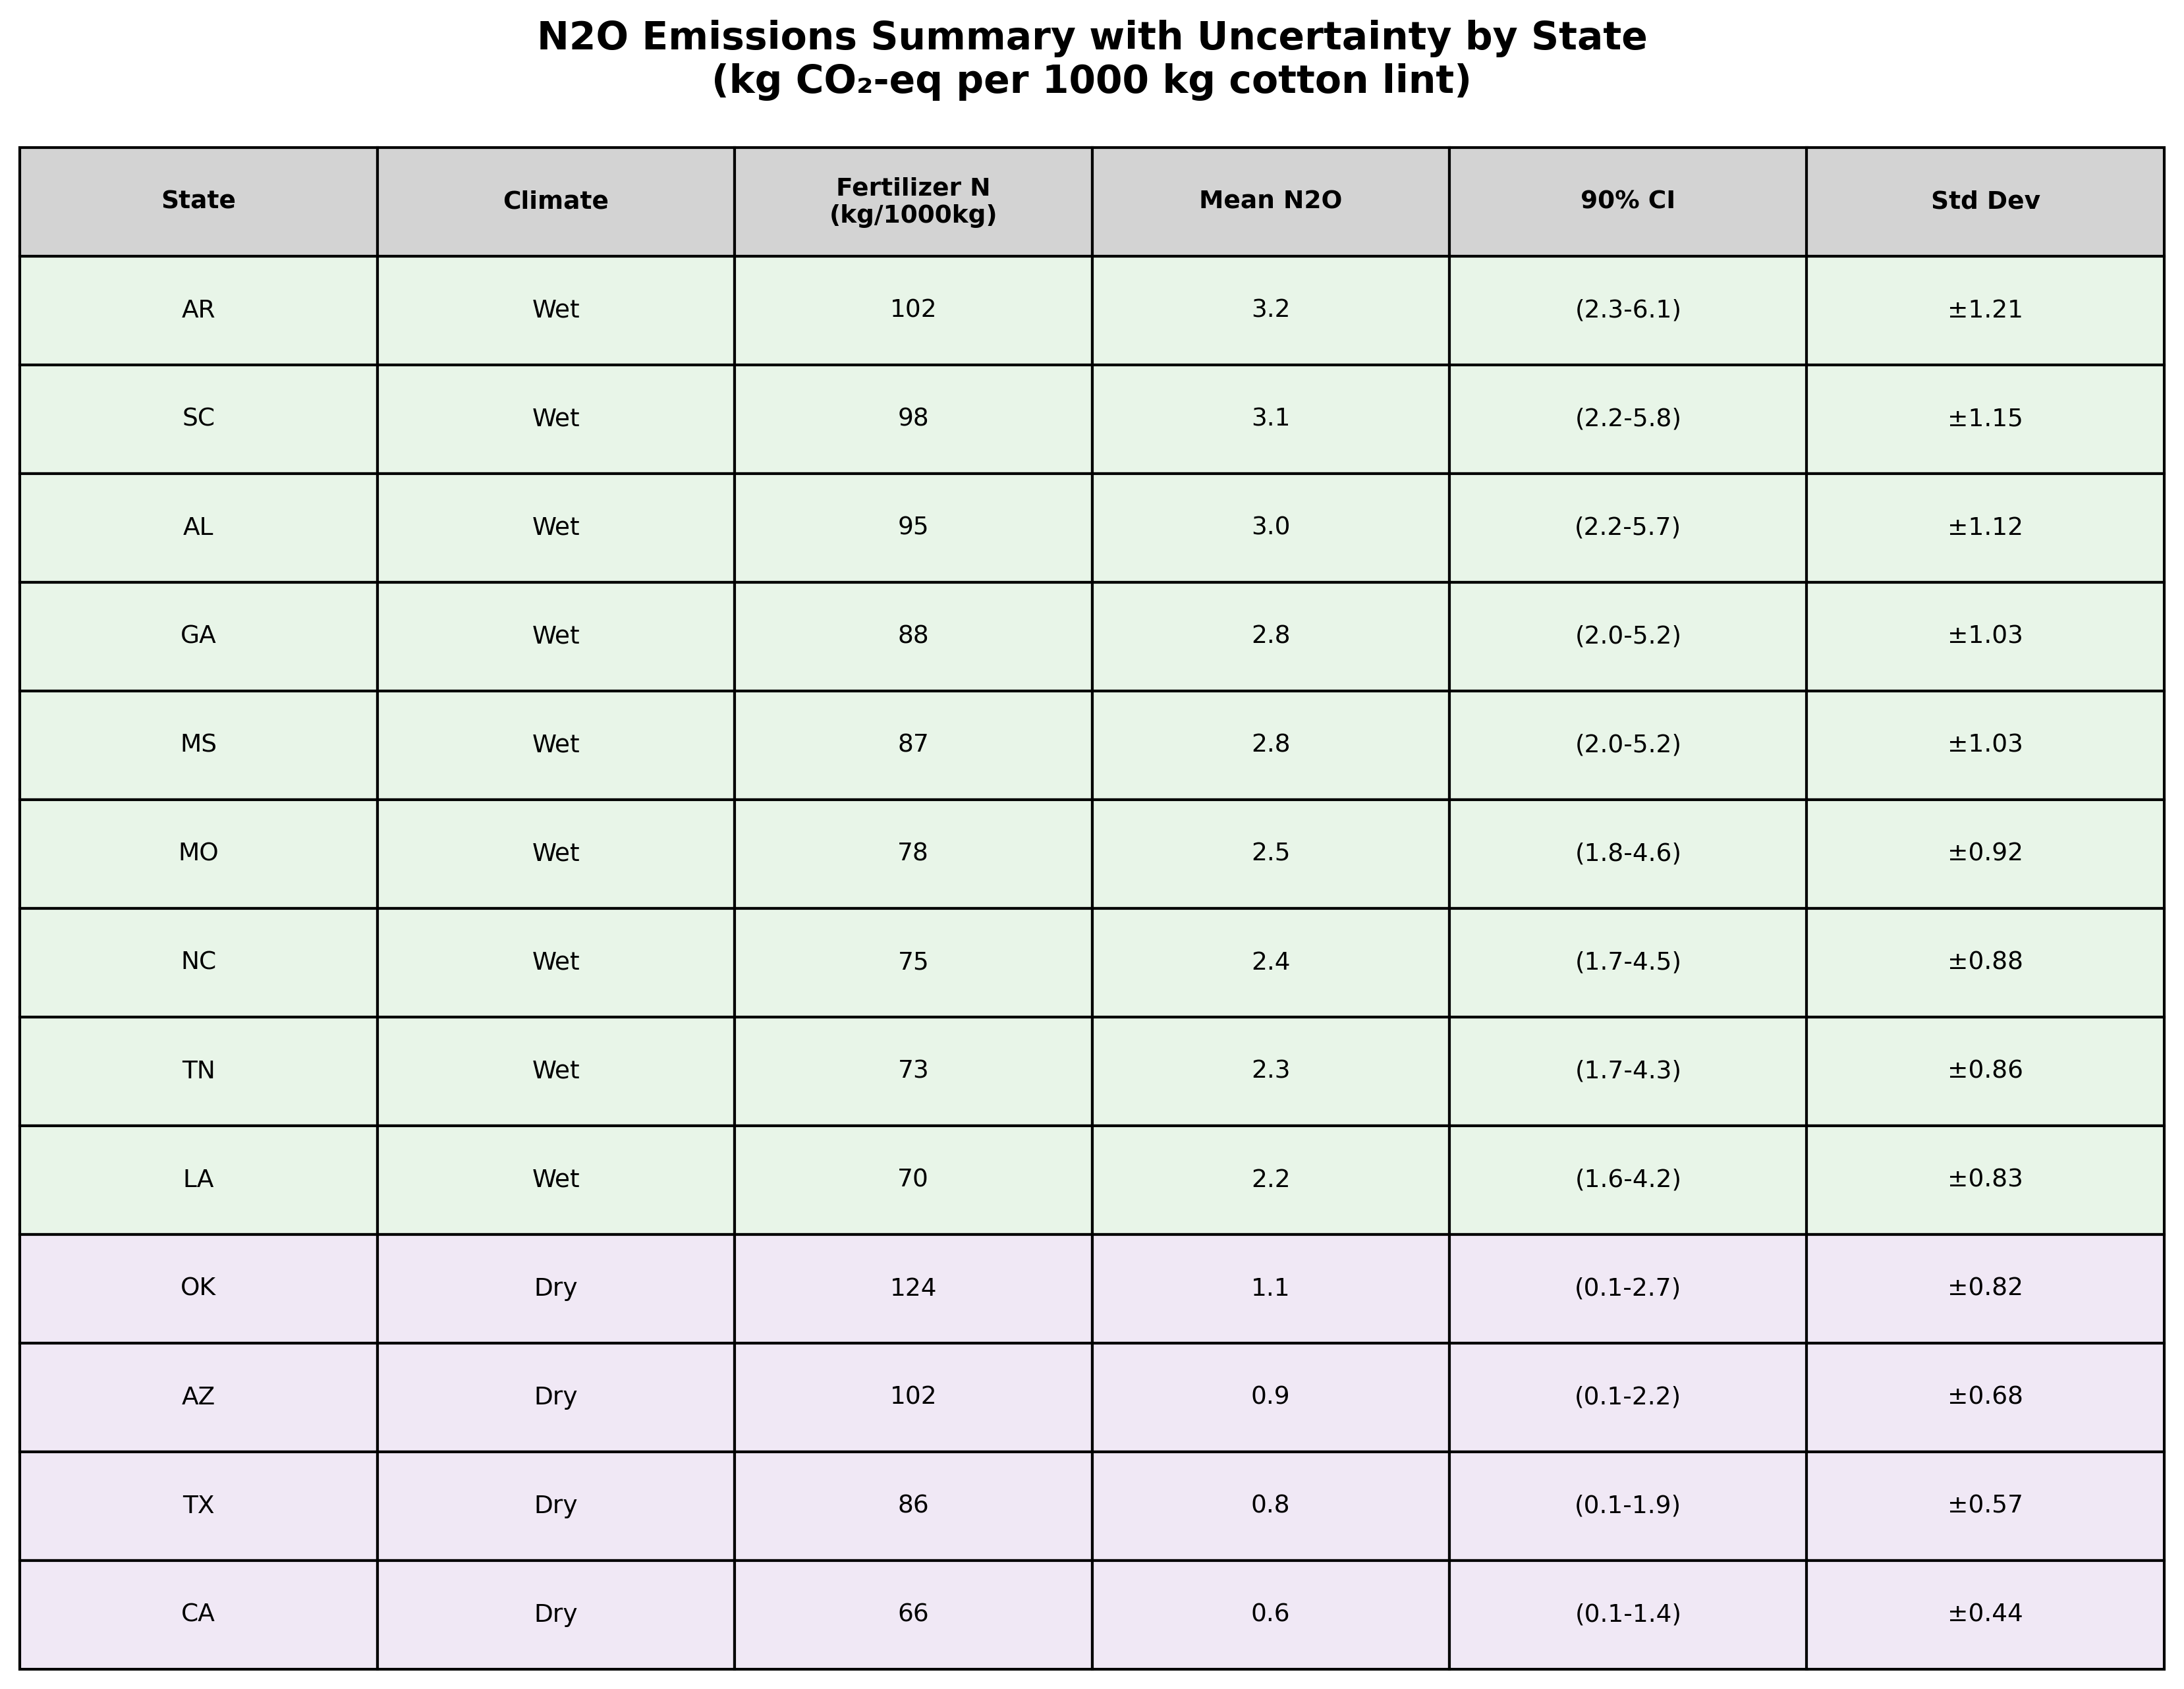

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# CLIMATE CLASSIFICATION
# =============================================================================
# wet_climate_states = ['LA', 'AR', 'MS', 'TN', 'NC', 'SC', 'GA', 'AL', 'FL', 'VA', 'MO']
# dry_climate_states = ['TX', 'AZ', 'CA', 'NM', 'NV', 'UT', 'CO', 'KS', 'OK']
wet_climate_states = ['LA', 'AR', 'MS', 'TN', 'NC', 'SC', 'GA', 'AL', 'MO']
dry_climate_states = ['TX', 'AZ', 'CA', 'OK']
def classify_climate(state):
    if state in wet_climate_states:
        return 'wet'
    elif state in dry_climate_states:
        return 'dry'
    else:
        return 'wet'

all_states = wet_climate_states + dry_climate_states
df = pd.DataFrame({'State': all_states})

df['Climate'] = df['State'].apply(classify_climate)

# =============================================================================
# EMISSION FACTORS (IPCC 2019 Guidelines)
# =============================================================================
# Direct emission factors with uncertainty ranges
EF1_wet_synthetic_mean, EF1_wet_synthetic_range = 0.016, (0.013, 0.019)
EF1_dry_all_mean, EF1_dry_all_range = 0.005, (0.000, 0.011)

# Indirect emission factors with uncertainty ranges
EF4_wet_mean, EF4_wet_range = 0.014, (0.011, 0.017)
EF4_dry_mean, EF4_dry_range = 0.005, (0.000, 0.011)
EF5_mean, EF5_range = 0.011, (0.000, 0.020)

# Volatilization and leaching fractions with uncertainty ranges
FracGASF_mean, FracGASF_range = 0.11, (0.02, 0.33)
FracLEACH_wet_mean, FracLEACH_wet_range = 0.24, (0.01, 0.73)
FracLEACH_dry = 0.0

# Molecular weight conversion factor
N2O_conversion = 44/28

# =============================================================================
# FERTILIZER NITROGEN DATA
'''
AL: 95.03
AZ: 101.74
AR: 102.31
CA: 65.76
GA: 87.57
LA: 70.38
MS: 87.44
MO: 77.92
NC: 74.65
OK: 123.54
SC: 97.59
TN: 72.66
TX: 85.68

national average: 86.91
'''

# =============================================================================
fertilizer_n_usage = {
    'AL': 95.03, 'AZ': 101.74, 'AR': 102.31, 'CA': 65.76, 'GA': 87.57,
    'LA': 70.38, 'MS': 87.44, 'MO': 77.92, 'NC': 74.65, 'OK': 123.54,
    'SC': 97.59, 'TN': 72.66, 'TX': 85.68
}

df['Fertilizer_N_usage'] = df['State'].map(fertilizer_n_usage)


# N2O EMISSION CALCULATIONS

def calculate_n2o_emissions_with_bounds(state, fertilizer_n, climate):
    """Calculate N2O emissions with uncertainty bounds using min/max parameter values"""

    # Set parameters based on climate
    if climate == 'wet':
        EF1_mean, EF1_range = EF1_wet_synthetic_mean, EF1_wet_synthetic_range
        EF4_mean, EF4_range = EF4_wet_mean, EF4_wet_range
        FracLEACH_mean, FracLEACH_range = FracLEACH_wet_mean, FracLEACH_wet_range
    else:
        EF1_mean, EF1_range = EF1_dry_all_mean, EF1_dry_all_range
        EF4_mean, EF4_range = EF4_dry_mean, EF4_dry_range
        FracLEACH_mean, FracLEACH_range = FracLEACH_dry, (FracLEACH_dry, FracLEACH_dry)

    # Calculate mean values
    N2O_direct_mean = fertilizer_n * EF1_mean * N2O_conversion
    N2O_indirect_vol_mean = fertilizer_n * FracGASF_mean * EF4_mean * N2O_conversion
    N2O_indirect_leach_mean = fertilizer_n * FracLEACH_mean * EF5_mean * N2O_conversion
    N2O_total_mean = N2O_direct_mean + N2O_indirect_vol_mean + N2O_indirect_leach_mean

    # Calculate minimum bounds (all parameters at minimum)
    N2O_direct_min = fertilizer_n * EF1_range[0] * N2O_conversion
    N2O_indirect_vol_min = fertilizer_n * FracGASF_range[0] * EF4_range[0] * N2O_conversion
    N2O_indirect_leach_min = fertilizer_n * FracLEACH_range[0] * EF5_range[0] * N2O_conversion
    N2O_total_min = N2O_direct_min + N2O_indirect_vol_min + N2O_indirect_leach_min

    # Calculate maximum bounds (all parameters at maximum)
    N2O_direct_max = fertilizer_n * EF1_range[1] * N2O_conversion
    N2O_indirect_vol_max = fertilizer_n * FracGASF_range[1] * EF4_range[1] * N2O_conversion
    N2O_indirect_leach_max = fertilizer_n * FracLEACH_range[1] * EF5_range[1] * N2O_conversion
    N2O_total_max = N2O_direct_max + N2O_indirect_vol_max + N2O_indirect_leach_max

    # Calculate approximate standard deviation (assuming uniform distribution)
    # For uniform distribution: std = (max - min) / sqrt(12)
    N2O_direct_std = (N2O_direct_max - N2O_direct_min) / np.sqrt(12)
    N2O_indirect_vol_std = (N2O_indirect_vol_max - N2O_indirect_vol_min) / np.sqrt(12)
    N2O_indirect_leach_std = (N2O_indirect_leach_max - N2O_indirect_leach_min) / np.sqrt(12)
    N2O_total_std = (N2O_total_max - N2O_total_min) / np.sqrt(12)

    # Calculate percentiles (assuming uniform distribution)
    # For uniform: p5 = min + 0.05*(max-min), p95 = min + 0.95*(max-min)
    N2O_total_p5 = N2O_total_min + 0.05 * (N2O_total_max - N2O_total_min)
    N2O_total_p25 = N2O_total_min + 0.25 * (N2O_total_max - N2O_total_min)
    N2O_total_p75 = N2O_total_min + 0.75 * (N2O_total_max - N2O_total_min)
    N2O_total_p95 = N2O_total_min + 0.95 * (N2O_total_max - N2O_total_min)

    return {
        # Mean values
        'N2O_direct_mean': N2O_direct_mean,
        'N2O_indirect_vol_mean': N2O_indirect_vol_mean,
        'N2O_indirect_leach_mean': N2O_indirect_leach_mean,
        'N2O_total_mean': N2O_total_mean,

        # Standard deviations
        'N2O_direct_std': N2O_direct_std,
        'N2O_indirect_vol_std': N2O_indirect_vol_std,
        'N2O_indirect_leach_std': N2O_indirect_leach_std,
        'N2O_total_std': N2O_total_std,

        # Percentiles (for total only, but can be calculated for components if needed)
        'N2O_total_p5': N2O_total_p5,
        'N2O_total_p25': N2O_total_p25,
        'N2O_total_p75': N2O_total_p75,
        'N2O_total_p95': N2O_total_p95,

        # Min/Max bounds
        'N2O_total_min': N2O_total_min,
        'N2O_total_max': N2O_total_max
    }

results = df.apply(lambda row: calculate_n2o_emissions_with_bounds(
    row['State'], row['Fertilizer_N_usage'], row['Climate']), axis=1)

for key in results.iloc[0].keys():
    df[key] = [result[key] for result in results]

# For backward compatibility
for component in ['N2O_direct', 'N2O_indirect_vol', 'N2O_indirect_leach', 'N2O_total']:
    df[component] = df[f'{component}_mean']


# VISUALIZATION


# Combined plot - N2O emissions by state and climate comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.92, 6), gridspec_kw={'width_ratios': [3, 1]})

# Left plot: Stacked bar chart by state with error bars
df_sorted = df.sort_values('N2O_total_mean', ascending=True)
y_pos = np.arange(len(df_sorted))

ax1.barh(y_pos, df_sorted['N2O_direct_mean'], label='Direct N₂O', color='#A4D5B1', alpha=0.8)
ax1.barh(y_pos, df_sorted['N2O_indirect_vol_mean'], left=df_sorted['N2O_direct_mean'],
         label='Indirect (Volatilization)', color='#A88EC0', alpha=0.8)
ax1.barh(y_pos, df_sorted['N2O_indirect_leach_mean'],
         left=df_sorted['N2O_direct_mean'] + df_sorted['N2O_indirect_vol_mean'],
         label='Indirect (Leaching)', color='#F4A261', alpha=0.8)

total_means = df_sorted['N2O_total_mean'].values
lower_errors = total_means - df_sorted['N2O_total_p5'].values
upper_errors = df_sorted['N2O_total_p95'].values - total_means

ax1.errorbar(total_means, y_pos, xerr=[lower_errors, upper_errors],
             fmt='none', ecolor='black', capsize=3, capthick=1, alpha=0.7, linewidth=1)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_sorted['State'])
ax1.set_xlabel('N₂O Emissions (kg N₂O/1000kg cotton lint)')
ax1.legend(frameon=False, bbox_to_anchor=(1.05, 0), loc='lower left')
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    mean_val, p5_val, p95_val = row['N2O_total_mean'], row['N2O_total_p5'], row['N2O_total_p95']
    ax1.text(mean_val + (p95_val - mean_val) + 0.25, i,
             f'{mean_val:.1f} ({p5_val:.1f}-{p95_val:.1f})',
             va='center', fontsize=8, ha='left')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right plot: Climate comparison with error bars
climate_means = df.groupby('Climate')[['N2O_direct_mean', 'N2O_indirect_vol_mean', 'N2O_indirect_leach_mean']].mean()
climate_totals_mean = df.groupby('Climate')['N2O_total_mean'].mean()
climate_totals_std = df.groupby('Climate')['N2O_total_std'].mean()

width = 0.6
x_pos = np.arange(len(climate_means))

ax2.bar(x_pos, climate_means['N2O_direct_mean'], width, label='Direct', color='#A4D5B1', alpha=0.8)
ax2.bar(x_pos, climate_means['N2O_indirect_vol_mean'], width,
        bottom=climate_means['N2O_direct_mean'], label='Volatilization', color='#A88EC0', alpha=0.8)
ax2.bar(x_pos, climate_means['N2O_indirect_leach_mean'], width,
        bottom=climate_means['N2O_direct_mean'] + climate_means['N2O_indirect_vol_mean'],
        label='Leaching', color='#F4A261', alpha=0.8)

ax2.errorbar(x_pos, climate_totals_mean.values, yerr=climate_totals_std.values,
             fmt='none', ecolor='black', capsize=5, capthick=1, linewidth=1)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Dry', 'Wet'])
ax2.set_ylabel('National Average N₂O Emissions (kg N₂O/1000kg cotton lint)')

for i, climate in enumerate(['dry', 'wet']):
    total_mean, total_std = climate_totals_mean.iloc[i], climate_totals_std.iloc[i]
    ax2.text(i, total_mean + total_std+0.1,
             f'{total_mean:.1f}±{total_std:.1f}', ha='left', fontsize=8)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/n2o/N2O_emission.tiff', dpi=300, bbox_inches='tight')

plt.show()

# =============================================================================
# SUMMARY TABLE
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('tight')
ax.axis('off')

summary_data = df[['State', 'Climate', 'Fertilizer_N_usage', 'N2O_total_mean',
                   'N2O_total_p5', 'N2O_total_p95', 'N2O_total_std']].round(2)
summary_data = summary_data.sort_values('N2O_total_mean', ascending=False)

display_data = []
for idx, row in summary_data.iterrows():
    display_data.append([
        row['State'], row['Climate'].capitalize(), f"{row['Fertilizer_N_usage']:.0f}",
        f"{row['N2O_total_mean']:.1f}", f"({row['N2O_total_p5']:.1f}-{row['N2O_total_p95']:.1f})",
        f"±{row['N2O_total_std']:.2f}"
    ])

table = ax.table(cellText=display_data,
                colLabels=['State', 'Climate', 'Fertilizer N\n(kg/1000kg)', 'Mean N2O',
                          '90% CI', 'Std Dev'],
                cellLoc='center', loc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

for i in range(len(display_data)):
    climate = summary_data.iloc[i]['Climate']
    base_color = '#E8F5E8' if climate == 'wet' else '#F0E8F5'

    for j in range(len(display_data[0])):
        table[(i+1, j)].set_facecolor(base_color)

for j in range(len(display_data[0])):
    table[(0, j)].set_facecolor('#D3D3D3')
    table[(0, j)].set_text_props(weight='bold')

plt.title('N2O Emissions Summary with Uncertainty by State\n(kg CO₂-eq per 1000 kg cotton lint)',
          fontsize=14, fontweight='bold', pad=20)
plt.show()